In [1]:
# Generated from output/jupyter-notebook/instance-validation-and-exploratory-analysis.ipynb
# Run as a percent script in editors that support `# %%` cells, or as plain Python.

# Experiment: Instance Validation and Exploratory Analysis

**Objetivo**

Usar o próprio notebook como workspace interativo principal para validar e explorar o release oficial `v1.1.0-observed`, reaproveitando o backend consolidado em `tools/instance_analysis_repl.py`.

**O que este notebook cobre**

- inventário do release oficial e contexto estrutural
- validação estrutural e reconciliação dos audits
- comportamento da camada observacional
- sanidade operacional por regime
- drilldown visual de uma instância concreta

**Modo de uso**

Este notebook é a interface interativa principal. O módulo `tools/instance_analysis_repl.py` funciona como backend compartilhado da análise, para evitar duas implementações diferentes do mesmo pipeline analítico.

In [2]:
# Setup: notebook runtime, paths and shared backend
from __future__ import annotations

import importlib
import json
import sys
from pathlib import Path

import matplotlib

NON_INTERACTIVE_CLI = __name__ == "__main__" and "ipykernel" not in sys.modules
if NON_INTERACTIVE_CLI:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

if NON_INTERACTIVE_CLI:
    plt.show = lambda *args, **kwargs: None


def find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (
            (candidate / "instances").exists()
            and (candidate / "catalog").exists()
            and (candidate / "tools").exists()
        ):
            return candidate
    raise RuntimeError(
        "Could not locate repository root from current working directory."
    )


REPO_ROOT = find_repo_root(Path.cwd().resolve())
ARTIFACT_DIR = (
    REPO_ROOT / "output" / "jupyter-notebook" / "instance_validation_analysis_artifacts"
)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

TOOLS_DIR = REPO_ROOT / "tools"
if str(TOOLS_DIR) not in sys.path:
    sys.path.insert(0, str(TOOLS_DIR))

import instance_analysis_repl as repl

repl = importlib.reload(repl)

SEED = repl.SEED
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)

STAGE_ORDER = repl.STAGE_ORDER
REGIME_ORDER = repl.REGIME_ORDER
SCALE_ORDER = repl.SCALE_ORDER

## Plan

1. Carregar o backend analítico compartilhado e expor os objetos principais no notebook.
2. Validar integridade estrutural, reconciliar audits e inspecionar métricas agregadas do release.
3. Verificar se a camada observacional reduz sobre-determinismo sem quebrar a semântica operacional.
4. Fazer drilldown visual em uma instância para checagem manual do baseline FIFO.

In [3]:
# Bootstrap the notebook workspace from the shared REPL backend
CTX = repl.CTX
SUMMARY = repl.SUMMARY
NOTEBOOK_CTX = dict(repl.CTX)
NOTEBOOK_CTX["artifact_dir"] = ARTIFACT_DIR

params = repl.PARAMS.copy()
catalog = repl.CATALOG.copy()
family_summary = repl.FAMILY_SUMMARY.copy()
observed_noise_manifest = repl.OBSERVED_NOISE_MANIFEST
manifest = repl.MANIFEST

jobs = repl.JOBS.copy()
jobs_enriched = repl.JOBS_ENRICHED.copy()
operations = repl.OPERATIONS.copy()
eligible = repl.ELIGIBLE.copy()
machines = repl.MACHINES.copy()
precedences = repl.PRECEDENCES.copy()
downtimes = repl.DOWNTIMES.copy()
events = repl.EVENTS.copy()
schedule = repl.SCHEDULE.copy()
job_metrics = repl.JOB_METRICS.copy()
due_audit = repl.DUE_AUDIT.copy()
proc_audit = repl.PROC_AUDIT.copy()
proc_audit_enriched = repl.PROC_AUDIT_ENRICHED.copy()
congestion = repl.CONGESTION.copy()

structural_report = repl.STRUCTURAL_REPORT.copy()
event_report = repl.EVENT_REPORT.copy()
audit_reconciliation = repl.AUDIT_RECONCILIATION.copy()
regime_checks = repl.REGIME_CHECKS.copy()
fifo_schema_report = repl.FIFO_SCHEMA_REPORT.copy()
utilization = repl.UTILIZATION.copy()
diagnostics = repl.DIAGNOSTICS.copy()
unload = repl.UNLOAD.copy()

validation_observed = pd.read_csv(
    REPO_ROOT / "catalog" / "validation_report_observed.csv"
)
validation_nominal_style = pd.read_csv(REPO_ROOT / "catalog" / "validation_report.csv")
g2milp_contract = json.loads(
    (REPO_ROOT / "catalog" / "g2milp_generation_contract.json").read_text(
        encoding="utf-8"
    )
)

inventory_summary = pd.DataFrame([SUMMARY])
display(inventory_summary)
display(
    Markdown(
        """
**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_congestion_diagnostics()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01")`
"""
    )
)

,dataset_version,instance_count,job_count,operation_count,eligible_rows,machine_rows,structural_pass_rate,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,fifo_schema_checks_pass,flow_regime_order_checks_pass,queue_regime_order_checks_pass,congestion_mean_regime_order_checks_pass,g2milp_role
0,1.1.0-observed,36,1848,7392,21167,306,1.0,1.0,1.0,0.4848,0.4995,True,True,True,False,base_dataset_for_g2milp_instance_generation



**Quick start interativo**

- `SUMMARY`
- `params.head()`
- `structural_report.head()`
- `repl.plot_inventory_overview()`
- `repl.plot_validation_overview()`
- `repl.plot_observational_layer()`
- `repl.plot_congestion_diagnostics()`
- `repl.plot_operational_sanity()`
- `repl.plot_instance_drilldown("GO_XS_DISRUPTED_01")`


In [4]:
# Release metadata and provenance checks
noise_manifest_summary = pd.DataFrame(
    [
        {
            "dataset_version": manifest["dataset_version"],
            "official_dataset_role": manifest["official_dataset_role"],
            "noise_model_id": observed_noise_manifest.get("model_id"),
            "noise_global_seed": observed_noise_manifest.get("global_seed"),
            "parent_dataset_version": observed_noise_manifest.get(
                "parent_dataset_version"
            ),
            "generator_model": observed_noise_manifest.get(
                "generator_model", "ChatGPT 5.4 PRO"
            ),
        }
    ]
)

display(params.head())
display(noise_manifest_summary)
display(pd.DataFrame([g2milp_contract]).iloc[:, :8])

,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
0,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_01,L,balanced,1,41111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,817207134
1,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_02,L,balanced,2,42111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,3851404905
2,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_BALANCED_03,L,balanced,3,43111,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,482397280
3,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_01,L,disrupted,1,41333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,569216366
4,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_L_DISRUPTED_02,L,disrupted,2,42333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,1131596359


,dataset_version,official_dataset_role,noise_model_id,noise_global_seed,parent_dataset_version,generator_model
0,1.1.0-observed,base_dataset_for_g2milp_instance_generation,pequiflux_observed_noise_v1_1,20260327,None,ChatGPT 5.4 PRO


,official_dataset_role,parent_dataset_version,generator_model_family,dataset_is_frozen_parent,required_child_lineage_fields,minimum_child_validation_requirements,documentation_ref
0,base_dataset_for_g2milp_instance_generation,1.1.0-observed,G2MILP,True,"[parent_dataset_name, parent_dataset_version, ...",[four_operations_per_job_or_declared_structura...,docs/g2milp_generation_contract.md


## Inventory and structural context

Esta seção responde:

- quantas instâncias, jobs, operações, máquinas e linhas elegíveis existem
- como as famílias `XS/S/M/L` e os regimes `balanced/peak/disrupted` estão distribuídos
- se os artefatos de auditoria e catálogo estão completos

,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
0,GO_L_BALANCED_01,instances/GO_L_BALANCED_01,L,balanced,1,41111,72,13,4,3,6,0,0.0278,0.7500,38.78,24.08,670,52.99,68,0.0,metaheuristic
1,GO_L_BALANCED_02,instances/GO_L_BALANCED_02,L,balanced,2,42111,72,13,4,3,6,0,0.0278,0.7500,37.89,24.33,681,58.69,87,0.0,metaheuristic
2,GO_L_BALANCED_03,instances/GO_L_BALANCED_03,L,balanced,3,43111,72,13,4,3,6,0,0.0278,0.7500,38.81,25.91,655,50.44,57,0.0,metaheuristic
3,GO_L_DISRUPTED_01,instances/GO_L_DISRUPTED_01,L,disrupted,1,41333,96,13,4,3,6,3,0.1979,0.5938,38.57,28.56,617,101.03,148,0.0,metaheuristic
4,GO_L_DISRUPTED_02,instances/GO_L_DISRUPTED_02,L,disrupted,2,42333,96,13,4,3,6,2,0.1771,0.6354,37.85,24.08,591,93.40,150,0.0,metaheuristic
5,GO_L_DISRUPTED_03,instances/GO_L_DISRUPTED_03,L,disrupted,3,43333,96,13,4,3,6,2,0.1875,0.5938,37.96,25.93,601,93.71,141,0.0,metaheuristic
6,GO_L_PEAK_01,instances/GO_L_PEAK_01,L,peak,1,41222,96,13,4,3,6,0,0.0833,0.6562,38.25,25.81,643,94.60,163,0.0,metaheuristic
7,GO_L_PEAK_02,instances/GO_L_PEAK_02,L,peak,2,42222,96,13,4,3,6,0,0.1354,0.7083,38.06,25.49,662,73.54,112,0.0,metaheuristic
8,GO_L_PEAK_03,instances/GO_L_PEAK_03,L,peak,3,43222,96,13,4,3,6,0,0.0729,0.6354,38.07,23.50,671,78.89,127,0.0,metaheuristic
9,GO_M_BALANCED_01,instances/GO_M_BALANCED_01,M,balanced,1,31111,48,9,3,2,4,0,0.0417,0.7292,37.79,27.74,673,55.35,68,0.0,hybrid


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


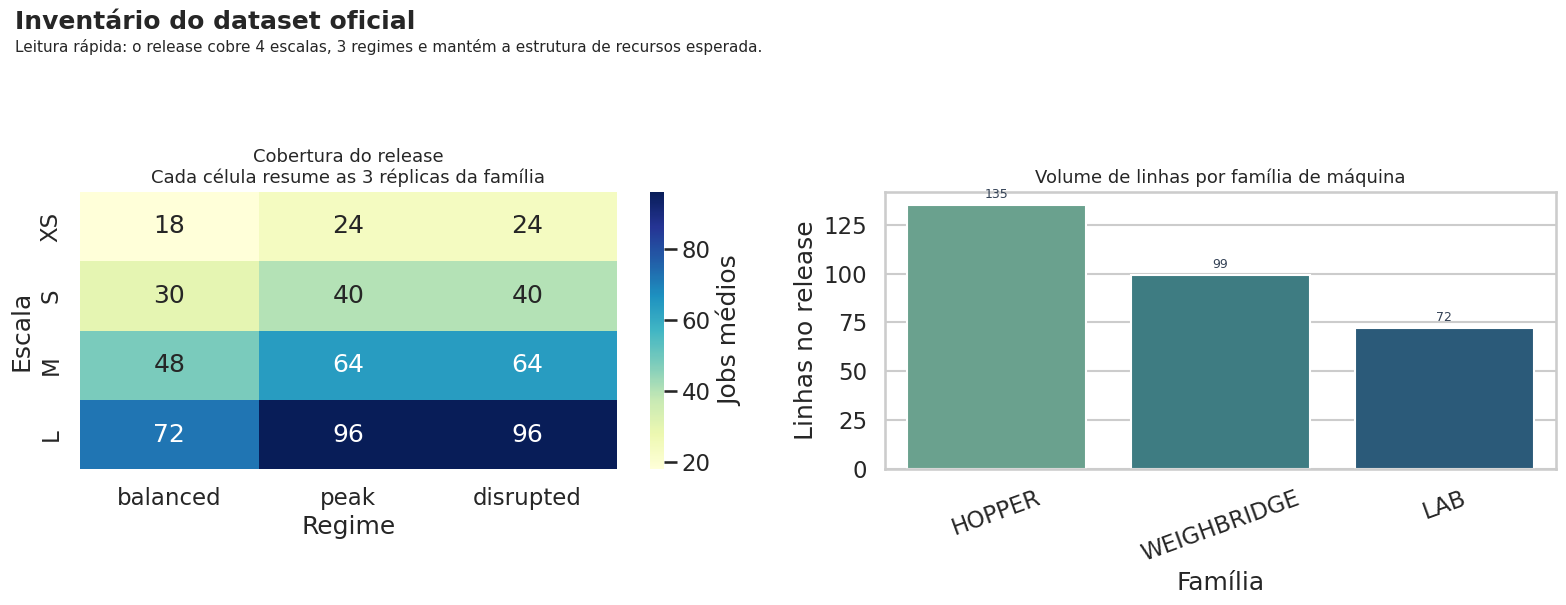

In [5]:
display(catalog.sort_values(["scale_code", "regime_code", "replicate"]).head(12))
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig = repl.plot_inventory_overview(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- o heatmap da esquerda mostra cobertura do release por família `escala x regime`
- as barras da direita mostram quantas linhas de recurso existem por família de máquina no release consolidado
- a figura serve como checagem de inventário, não de desempenho

## Structural validation and auditability

Aqui reaplicamos o verificador estrutural do release e complementamos com:

- executabilidade formal do baseline FIFO contra o schema
- consistência de eventos
- margem do prazo sobre o lower bound nominal
- reconciliação auditável entre arquivos centrais e CSVs de audit

,instance_id,issue_count,issues,status,scale_code,regime_code
0,GO_L_BALANCED_01,0,,PASS,L,balanced
1,GO_L_BALANCED_02,0,,PASS,L,balanced
2,GO_L_BALANCED_03,0,,PASS,L,balanced
3,GO_L_DISRUPTED_01,0,,PASS,L,disrupted
4,GO_L_DISRUPTED_02,0,,PASS,L,disrupted
5,GO_L_DISRUPTED_03,0,,PASS,L,disrupted
6,GO_L_PEAK_01,0,,PASS,L,peak
7,GO_L_PEAK_02,0,,PASS,L,peak
8,GO_L_PEAK_03,0,,PASS,L,peak
9,GO_M_BALANCED_01,0,,PASS,M,balanced


,instance_id,eligible_assignment_ok,release_time_ok,precedence_ok,machine_overlap_ok,downtime_ok,ineligible_assignments,release_time_violations,precedence_violations,machine_overlap_violations,downtime_violations,scale_code,regime_code
0,GO_L_BALANCED_01,True,True,True,True,True,0,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,True,True,True,True,True,0,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,True,True,True,True,True,0,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,True,True,True,True,True,0,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,True,True,True,True,True,0,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,True,True,True,True,True,0,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,True,True,True,True,True,0,0,0,0,0,L,peak
7,GO_L_PEAK_02,True,True,True,True,True,0,0,0,0,0,L,peak
8,GO_L_PEAK_03,True,True,True,True,True,0,0,0,0,0,L,peak
9,GO_M_BALANCED_01,True,True,True,True,True,0,0,0,0,0,M,balanced


,instance_id,job_visible_mismatch,job_arrival_mismatch,machine_down_missing,machine_up_missing,scale_code,regime_code
0,GO_L_BALANCED_01,0,0,0,0,L,balanced
1,GO_L_BALANCED_02,0,0,0,0,L,balanced
2,GO_L_BALANCED_03,0,0,0,0,L,balanced
3,GO_L_DISRUPTED_01,0,0,0,0,L,disrupted
4,GO_L_DISRUPTED_02,0,0,0,0,L,disrupted
5,GO_L_DISRUPTED_03,0,0,0,0,L,disrupted
6,GO_L_PEAK_01,0,0,0,0,L,peak
7,GO_L_PEAK_02,0,0,0,0,L,peak
8,GO_L_PEAK_03,0,0,0,0,L,peak
9,GO_M_BALANCED_01,0,0,0,0,M,balanced


,instance_id,due_match_share,proc_match_share,scale_code,regime_code
0,GO_L_BALANCED_01,1.0,1.0,L,balanced
1,GO_L_BALANCED_02,1.0,1.0,L,balanced
2,GO_L_BALANCED_03,1.0,1.0,L,balanced
3,GO_L_DISRUPTED_01,1.0,1.0,L,disrupted
4,GO_L_DISRUPTED_02,1.0,1.0,L,disrupted
5,GO_L_DISRUPTED_03,1.0,1.0,L,disrupted
6,GO_L_PEAK_01,1.0,1.0,L,peak
7,GO_L_PEAK_02,1.0,1.0,L,peak
8,GO_L_PEAK_03,1.0,1.0,L,peak
9,GO_M_BALANCED_01,1.0,1.0,M,balanced


,index,scale_code,regime_code,mean,min,median,max
0,0,L,balanced,249.80,154,251.0,301
1,1,L,disrupted,258.99,141,264.0,353
2,2,L,peak,257.97,172,264.0,314
3,3,M,balanced,239.47,146,243.0,295
4,4,M,disrupted,262.74,158,269.0,331
5,5,M,peak,246.40,162,249.0,327
6,6,S,balanced,248.60,179,254.5,288
7,7,S,disrupted,255.80,189,261.0,331
8,8,S,peak,246.94,173,254.0,300
9,9,XS,balanced,233.09,169,237.5,268


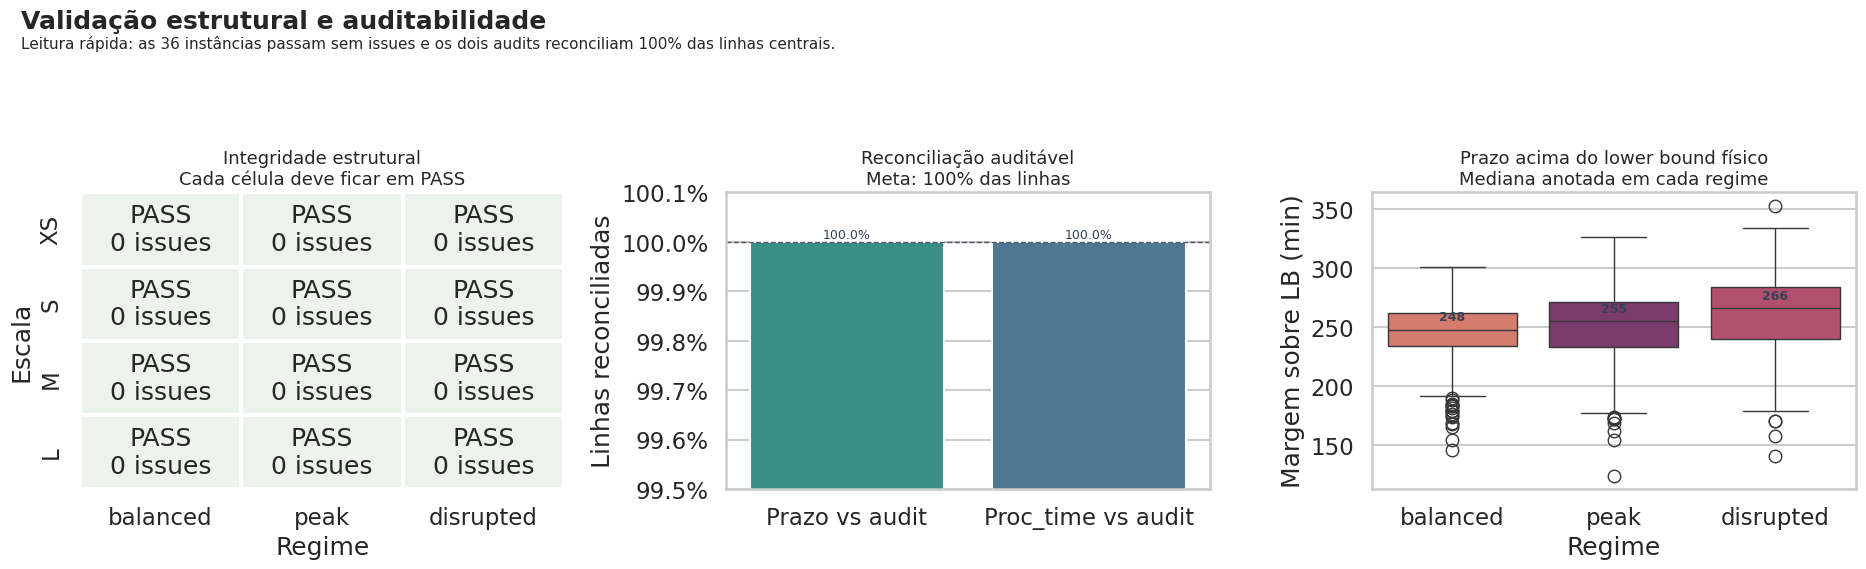

In [6]:
# The shared REPL backend already ships these reports with scale/regime context.

display(structural_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(fifo_schema_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(event_report.sort_values(["scale_code", "regime_code", "instance_id"]))
display(audit_reconciliation.sort_values(["scale_code", "regime_code", "instance_id"]))

due_margin_summary = (
    jobs_enriched.groupby(["scale_code", "regime_code"], as_index=False)[
        "due_margin_over_lb_min"
    ]
    .agg(["mean", "min", "median", "max"])
    .round(2)
    .reset_index()
)
display(due_margin_summary)

fig = repl.plot_validation_overview(ctx=NOTEBOOK_CTX, save=True)
plt.show()

structural_report.to_csv(ARTIFACT_DIR / "structural_report.csv", index=False)
fifo_schema_report.to_csv(ARTIFACT_DIR / "fifo_schema_report.csv", index=False)
event_report.to_csv(ARTIFACT_DIR / "event_report.csv", index=False)
audit_reconciliation.to_csv(ARTIFACT_DIR / "audit_reconciliation.csv", index=False)
due_margin_summary.to_csv(ARTIFACT_DIR / "due_margin_summary.csv", index=False)

**Como ler a figura acima**

- painel esquerdo: cada célula deve ficar em `PASS`; se aparecer número de issues, aquela família tem falhas estruturais
- a tabela `fifo_schema_report` formaliza a executabilidade do baseline FIFO: elegibilidade, `release_time`, precedência, overlap e downtime
- painel central: os dois bars precisam ficar em `100%`; qualquer queda indica quebra entre CSV central e CSV de audit
- painel direito: mostra quanta folga de prazo sobra acima do lower bound físico plausível

## Observational layer behavior

Esta seção testa se a camada observacional cumpriu seu papel:

- a prioridade continua importante, mas não perfeitamente determinística
- tempos de `UNLOAD` continuam interpretáveis por carga, máquina, umidade e congestionamento
- o ruído aparece de forma estruturada, e não como barulho arbitrário

,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture
0,0.4848,0.4995


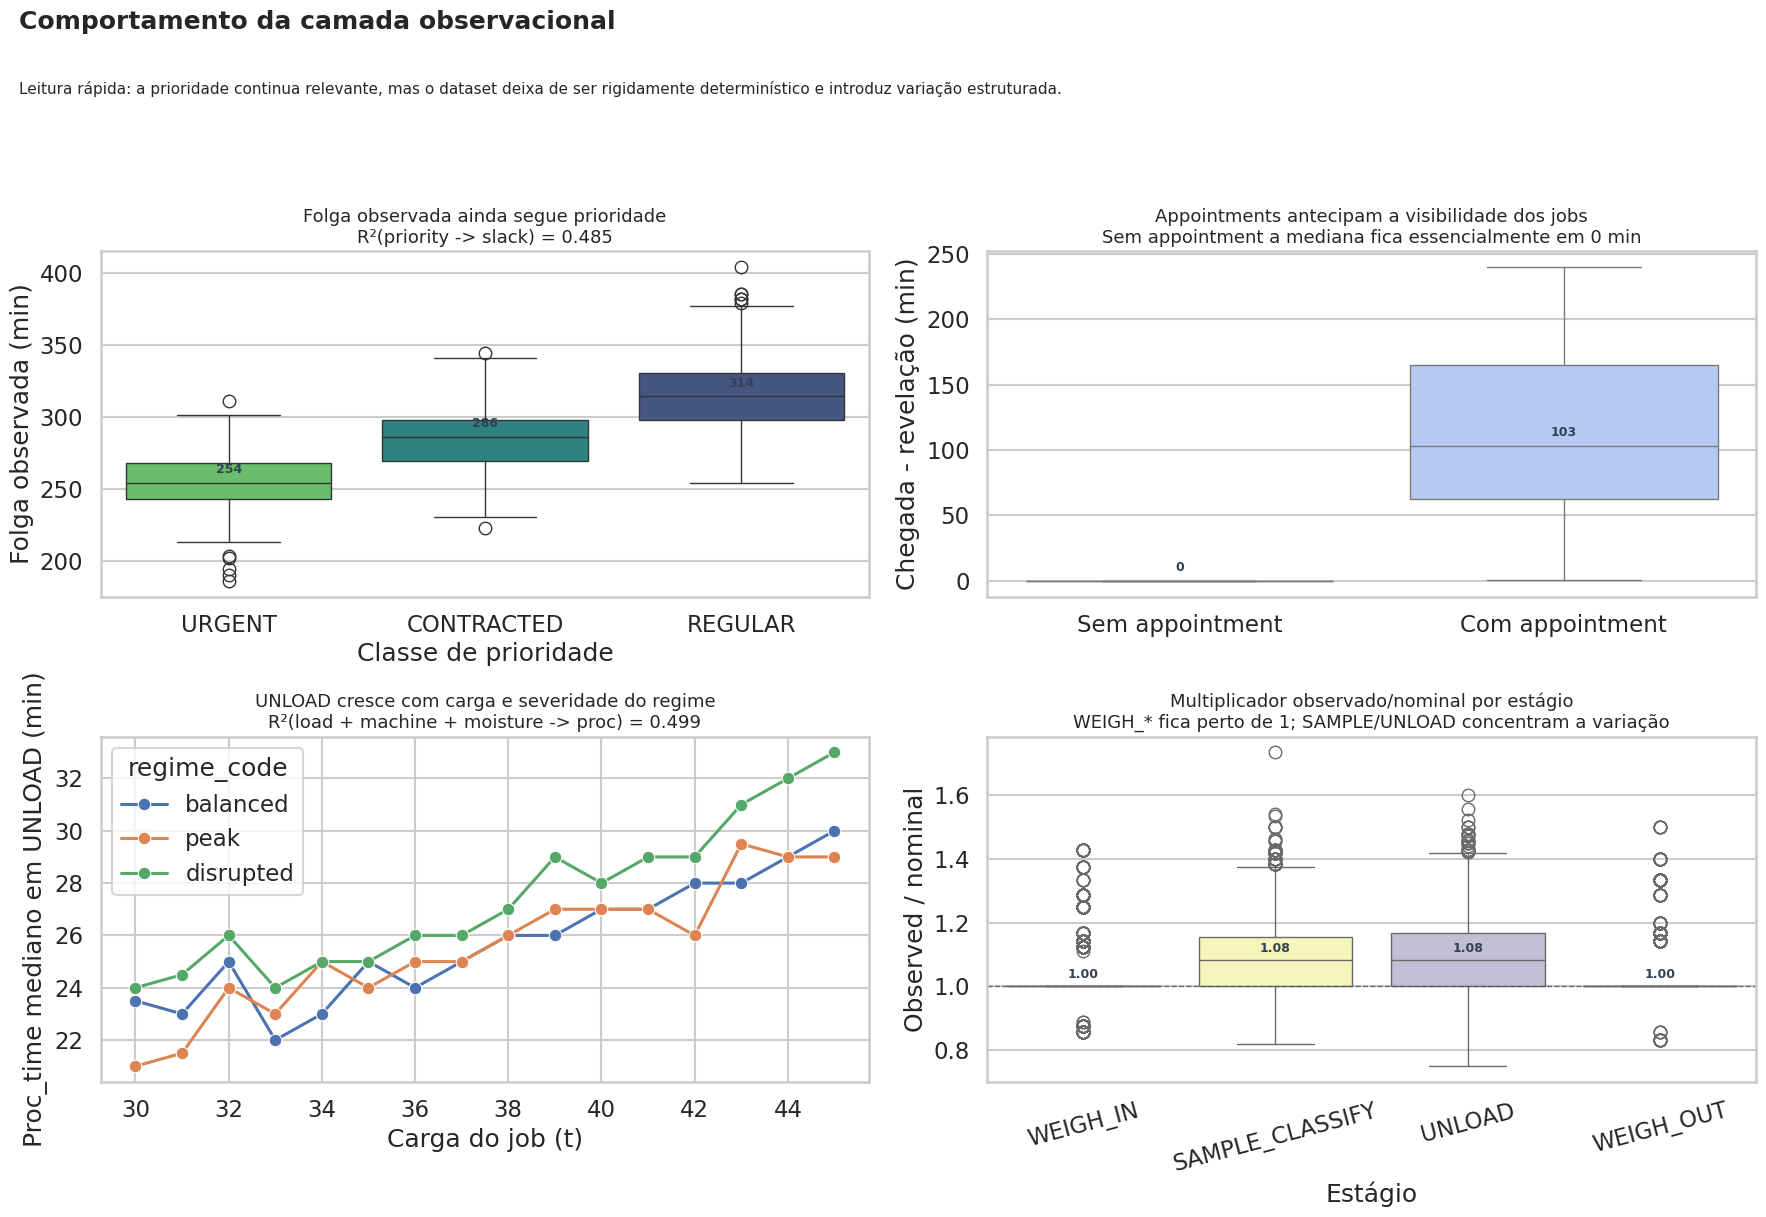

In [7]:
diagnostics_df = pd.DataFrame([diagnostics])
display(diagnostics_df)

fig = repl.plot_observational_layer(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- prioridade ainda ordena a folga de prazo, mas o `R²` abaixo de `0.5` mostra que ela não explica tudo sozinha
- `appointment` afeta visibilidade antes da chegada, o que ajuda a aproximar o benchmark de uma operação real
- em `UNLOAD`, a carga e o regime empurram o tempo mediano para cima
- os multiplicadores por estágio mostram onde a camada observacional realmente introduziu variação

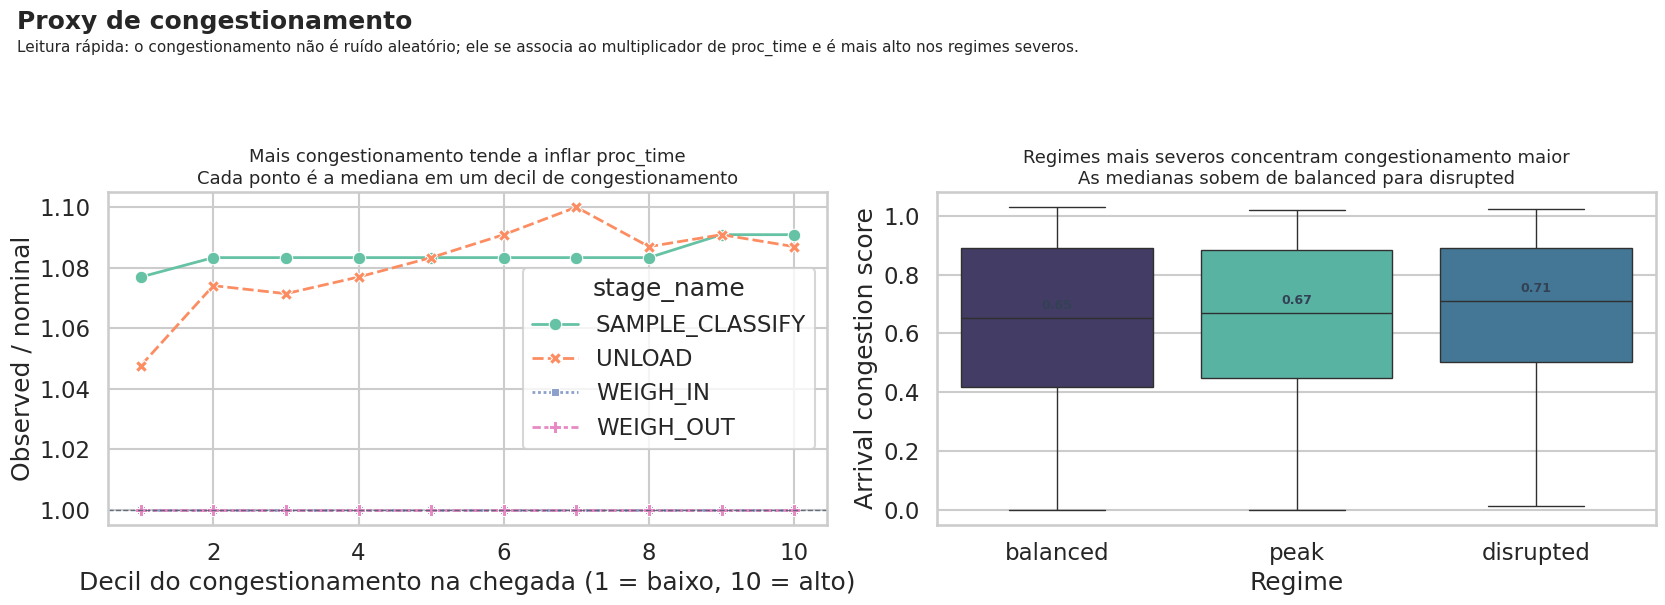

In [8]:
fig = repl.plot_congestion_diagnostics(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- no painel esquerdo, cada linha resume um estágio por decil de congestionamento; inclinação positiva significa que o proxy está influenciando `proc_time`
- no painel direito, `balanced`, `peak` e `disrupted` deveriam deslocar a distribuição para cima nessa ordem

## Operational performance and regime sanity

A validação não depende só de integridade estrutural. Também interessa saber se:

- `balanced < peak < disrupted` permanece verdadeiro para `mean_flow` e `p95_flow`
- a fila média também preserva monotonicidade
- o proxy médio de congestionamento não precisa ser monotônico em todas as famílias
- os tempos de fluxo e fila continuam coerentes com a escala do problema
- a utilização de recurso faz sentido por família de máquina

,scale_code,mean_flow_order_ok,p95_flow_order_ok,mean_queue_order_ok,mean_congestion_order_ok
0,L,True,True,True,True
1,M,True,True,True,False
2,S,True,True,True,True
3,XS,True,True,True,True


,scale_code,regime_code,instance_count,avg_n_jobs,avg_fifo_makespan_min,avg_fifo_mean_flow_min,avg_fifo_p95_flow_min,avg_fifo_overwait_share
0,L,balanced,3,72.0,668.67,54.04,70.67,0.00
1,L,disrupted,3,96.0,603.00,96.05,146.33,0.00
2,L,peak,3,96.0,658.67,82.34,134.00,0.00
3,M,balanced,3,48.0,677.00,54.52,66.33,0.00
4,M,disrupted,3,64.0,615.00,97.68,145.00,0.00
5,M,peak,3,64.0,646.33,71.02,106.33,0.00
6,S,balanced,3,30.0,690.00,59.10,78.33,0.00
7,S,disrupted,3,40.0,598.33,89.06,142.00,0.00
8,S,peak,3,40.0,632.33,74.23,107.67,0.00
9,XS,balanced,3,18.0,645.00,73.57,100.00,0.00


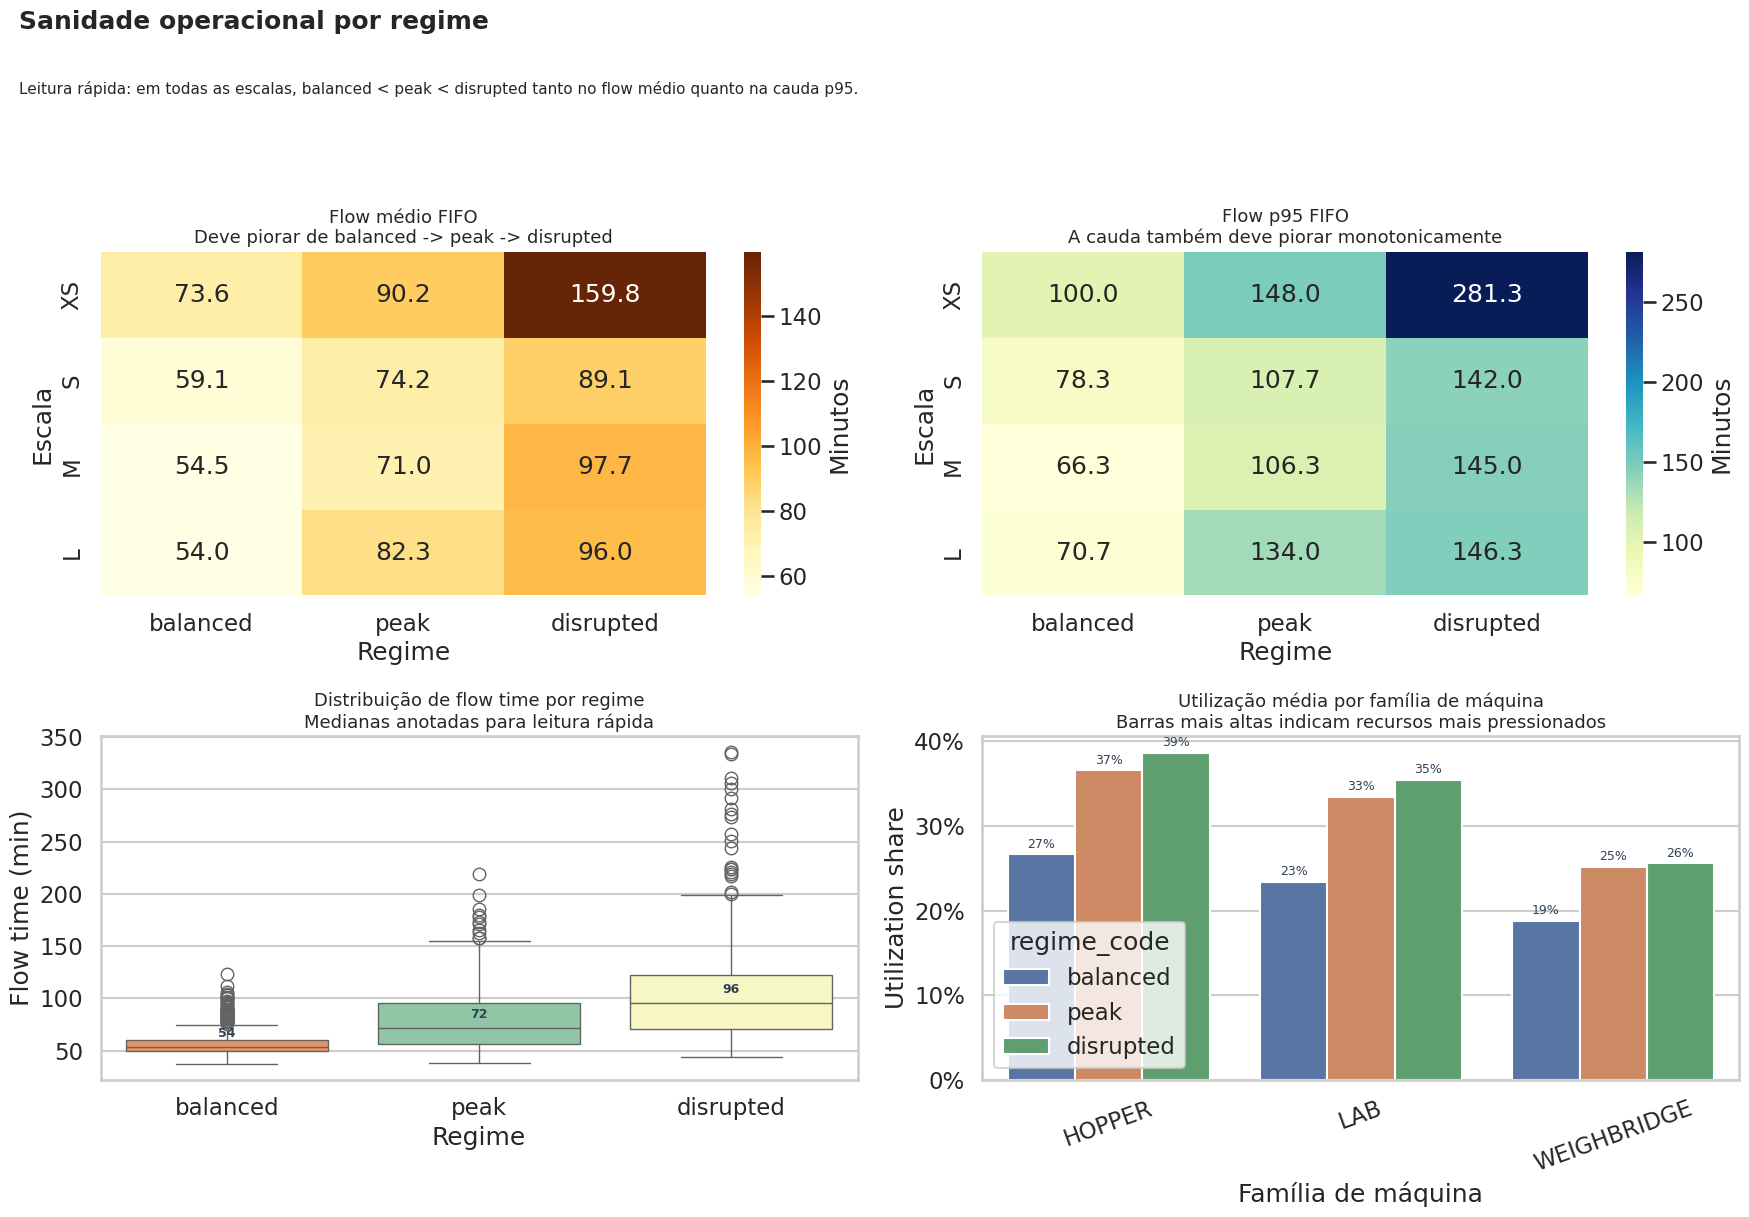

In [9]:
display(regime_checks)
display(family_summary.sort_values(["scale_code", "regime_code"]))

fig = repl.plot_operational_sanity(ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler a figura acima**

- os heatmaps do topo validam a monotonicidade esperada apenas para `flow`: `balanced < peak < disrupted`
- a tabela `regime_checks` separa formalmente os checks de `flow`, `queue` e `congestion`
- o boxplot inferior esquerdo mostra a distribuição de `flow_time` no nível de job
- o gráfico inferior direito ajuda a ver quais famílias de máquina absorvem mais pressão em cada regime

## Instance drilldown

Um drilldown ajuda a validar visualmente se o baseline FIFO de uma instância concreta:

- respeita o fluxo por máquina
- evita overlap
- incorpora downtimes
- produz métricas coerentes com o regime escolhido

,dataset_name,dataset_version,instance_id,scale_code,regime_code,replicate,random_seed,time_unit,load_unit,currency,planning_horizon_min,shift_open_min,shift_close_min,antt_statutory_wait_limit_min,antt_wait_cost_rs_per_ton_hour,notes,parent_dataset_version,observational_noise_model_id,observational_noise_seed
30,Agro Yard D-FJSP GO Benchmark,1.1.0-observed,GO_XS_DISRUPTED_01,XS,disrupted,1,11333,minute,ton,BRL,1080,0,720,300,2.41,Structured observational-noise derivative of t...,1.0.0,pequiflux_observed_noise_v1_1,2360242032


,instance_id,relative_path,scale_code,regime_code,replicate,random_seed,n_jobs,n_machines,n_scales,n_labs,n_hoppers,n_breakdowns,share_urgent,share_appointment,avg_load_tons,avg_unload_proc_time_min,fifo_makespan_min,fifo_mean_flow_min,fifo_p95_flow_min,fifo_overwait_share,recommended_solver_track
30,GO_XS_DISRUPTED_01,instances/GO_XS_DISRUPTED_01,XS,disrupted,1,11333,24,5,2,1,2,2,0.2083,0.4583,38.33,34.12,717,140.71,288,0.0417,exact


,job_id,commodity,load_tons,arrival_time_min,reveal_time_min,priority_class,priority_weight,appointment_flag,moisture_class,statutory_wait_limit_min,completion_due_min,overwait_cost_rs_per_min,shift_bucket,arrival_congestion_score,instance_id,scale_code,regime_code,replicate,dataset_version,nominal_lb_min,due_slack_min,due_margin_over_lb_min,reveal_lead_min
1704,J0001,SOY,35,37,37,CONTRACTED,1.25,0,NORMAL,300,343,1.4058,EARLY,0.322444,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,57,306,249,0
1705,J0002,SORGHUM,31,68,68,REGULAR,1.00,0,WET,300,413,1.2452,EARLY,0.820252,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,61,345,284,0
1706,J0003,CORN,45,70,7,CONTRACTED,1.25,1,NORMAL,300,340,1.8075,EARLY,0.842879,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,60,270,210,63
1707,J0004,CORN,35,71,64,URGENT,1.75,1,NORMAL,300,318,1.4058,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,53,247,194,7
1708,J0005,CORN,44,73,73,REGULAR,1.00,0,NORMAL,300,409,1.7673,EARLY,0.848536,GO_XS_DISRUPTED_01,XS,disrupted,1,1.1.0-observed,62,336,274,0


,completion_min,flow_time_min,queue_time_min,overwait_min,replicate
count,24.00,24.00,24.00,24.00,24.0
mean,369.42,140.71,78.92,1.42,1.0
std,190.25,71.99,71.23,6.94,0.0
min,94.00,57.00,0.00,0.00,1.0
25%,211.00,93.50,31.75,0.00,1.0
50%,354.50,126.50,66.50,0.00,1.0
75%,497.50,162.50,106.00,0.00,1.0
max,717.00,334.00,268.00,34.00,1.0


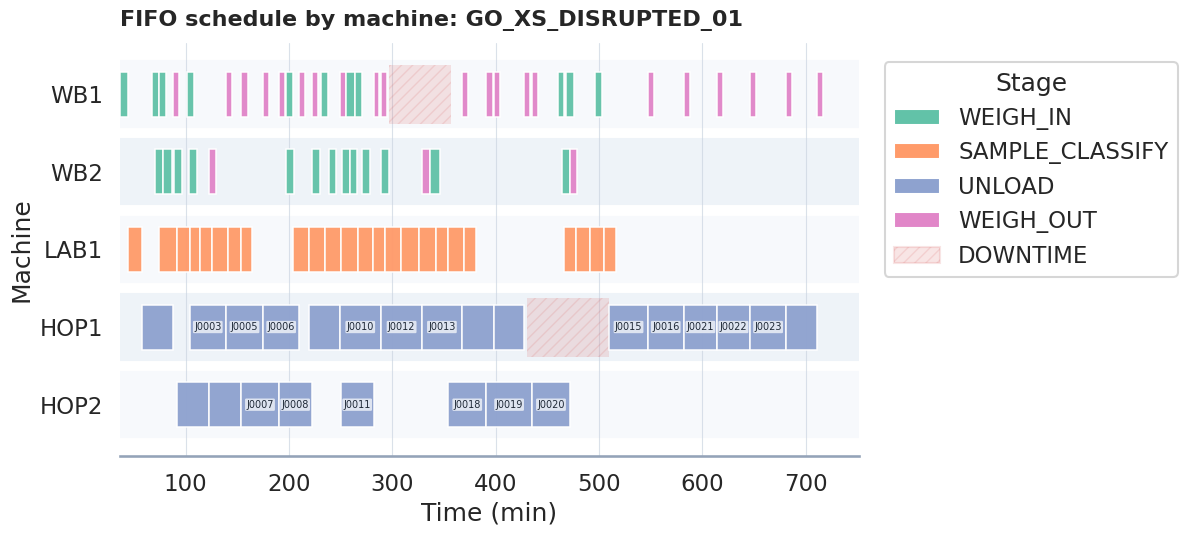

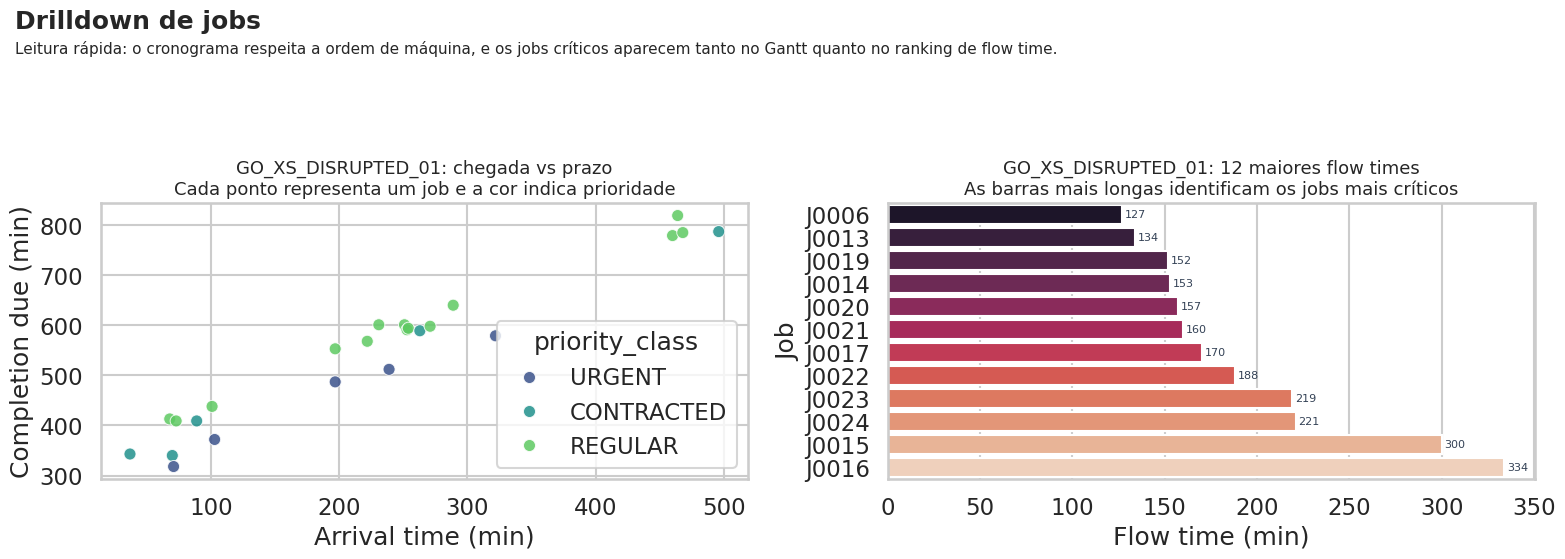

In [10]:
sample_instance = "GO_XS_DISRUPTED_01"

sample_params = params[params["instance_id"] == sample_instance]
sample_summary = catalog[catalog["instance_id"] == sample_instance]
sample_jobs = jobs_enriched[jobs_enriched["instance_id"] == sample_instance]
sample_metrics = job_metrics[job_metrics["instance_id"] == sample_instance]

display(sample_params)
display(sample_summary)
display(sample_jobs.head())
display(sample_metrics.describe().round(2))

fig = repl.plot_instance_drilldown(sample_instance, ctx=NOTEBOOK_CTX, save=True)
plt.show()

fig = repl.plot_job_level_views(sample_instance, ctx=NOTEBOOK_CTX, save=True)
plt.show()

**Como ler as figuras acima**

- o Gantt mostra ocupação por máquina, faixas de downtime e ausência de overlap no baseline FIFO
- o scatter de jobs ajuda a ver como os prazos se distribuem em função da chegada
- o ranking horizontal destaca os jobs mais críticos em `flow_time`

## Results and notes

O notebook consolida uma leitura de qualidade do release oficial:

- o release está estruturalmente íntegro
- o baseline FIFO é executável contra o schema nas `36` instâncias
- os audits reconciliam os valores centrais
- os checks de regime são positivos para `mean_flow`, `p95_flow` e fila média
- o proxy médio de congestionamento é útil, mas não monotônico em todas as famílias
- a camada observacional reduz determinismo excessivo sem destruir semântica
- a base é forte o suficiente para servir como dataset pai de análises e futuras derivações com G2MILP

In [11]:
summary = {
    "dataset_version": manifest["dataset_version"],
    "instance_count": int(params["instance_id"].nunique()),
    "structural_pass_rate": float((structural_report["status"] == "PASS").mean()),
    "fifo_schema_checks_pass": bool(
        fifo_schema_report[
            [
                "eligible_assignment_ok",
                "release_time_ok",
                "precedence_ok",
                "machine_overlap_ok",
                "downtime_ok",
            ]
        ].all(axis=None)
    ),
    "due_audit_match_share": float(audit_reconciliation["due_match_share"].mean()),
    "proc_audit_match_share": float(audit_reconciliation["proc_match_share"].mean()),
    "r2_due_slack_vs_priority": float(diagnostics["r2_due_slack_vs_priority"]),
    "r2_unload_proc_vs_load_machine_moisture": float(
        diagnostics["r2_unload_proc_vs_load_machine_moisture"]
    ),
    "flow_regime_order_checks_pass": bool(
        regime_checks["mean_flow_order_ok"].all()
        and regime_checks["p95_flow_order_ok"].all()
    ),
    "queue_regime_order_checks_pass": bool(regime_checks["mean_queue_order_ok"].all()),
    "congestion_mean_regime_order_checks_pass": bool(
        regime_checks["mean_congestion_order_ok"].all()
    ),
    "g2milp_role": manifest["official_dataset_role"],
}
summary_df = pd.DataFrame([summary])
display(summary_df)

summary_lines = [
    "# Notebook Summary",
    "",
    f"- Dataset version: `{summary['dataset_version']}`",
    f"- Instances: `{summary['instance_count']}`",
    f"- Structural pass rate: `{summary['structural_pass_rate']:.4f}`",
    f"- FIFO schema checks pass: `{summary['fifo_schema_checks_pass']}`",
    f"- Due audit match share: `{summary['due_audit_match_share']:.4f}`",
    f"- Proc audit match share: `{summary['proc_audit_match_share']:.4f}`",
    f"- R2 due slack vs priority: `{summary['r2_due_slack_vs_priority']:.4f}`",
    f"- R2 unload proc vs load+machine+moisture: `{summary['r2_unload_proc_vs_load_machine_moisture']:.4f}`",
    f"- Flow regime checks pass: `{summary['flow_regime_order_checks_pass']}`",
    f"- Mean queue regime checks pass: `{summary['queue_regime_order_checks_pass']}`",
    f"- Mean congestion regime checks pass: `{summary['congestion_mean_regime_order_checks_pass']}`",
    f"- Official role: `{summary['g2milp_role']}`",
]
summary_text = "\n".join(summary_lines)
(ARTIFACT_DIR / "notebook_summary.md").write_text(summary_text, encoding="utf-8")
summary_df.to_csv(ARTIFACT_DIR / "notebook_summary.csv", index=False)
display(Markdown(summary_text))

,dataset_version,instance_count,structural_pass_rate,fifo_schema_checks_pass,due_audit_match_share,proc_audit_match_share,r2_due_slack_vs_priority,r2_unload_proc_vs_load_machine_moisture,flow_regime_order_checks_pass,queue_regime_order_checks_pass,congestion_mean_regime_order_checks_pass,g2milp_role
0,1.1.0-observed,36,1.0,True,1.0,1.0,0.4848,0.4995,True,True,False,base_dataset_for_g2milp_instance_generation


# Notebook Summary

- Dataset version: `1.1.0-observed`
- Instances: `36`
- Structural pass rate: `1.0000`
- FIFO schema checks pass: `True`
- Due audit match share: `1.0000`
- Proc audit match share: `1.0000`
- R2 due slack vs priority: `0.4848`
- R2 unload proc vs load+machine+moisture: `0.4995`
- Flow regime checks pass: `True`
- Mean queue regime checks pass: `True`
- Mean congestion regime checks pass: `False`
- Official role: `base_dataset_for_g2milp_instance_generation`

## Next steps

- usar este notebook como baseline de validação antes de gerar filhos com G2MILP
- ampliar com comparações entre esta release oficial e futuros datasets derivados
- adicionar testes de sensibilidade por família de máquina ou por política de geração